# 24K-0015, Syed Zahid Hussain, BAI-4A
---
# 🌱 Irrigation Need Prediction — Full ML Pipeline
**Target:** `Irrigation_Need` → Low / Medium / High

---
## Cell Layout Guide
| # | Cell | Purpose |
|---|------|---------|
| 1 | Setup & Imports | All libraries |
| 2 | Load Data | Read CSVs |
| 3 | EDA | Distributions, class balance |
| 4 | Preprocessing | Encode, scale, impute |
| 5 | Feature Engineering | New features |
| 6 | Feature Selection (RFE) | Top 15–20 features |
| **7** | **← INSERT: Logistic Regression** | Base model |
| **8** | **← INSERT: Naive Bayes** | Base model |
| **9** | **← INSERT: Decision Tree** | Base model |
| 10 | XGBoost | Booster |
| 11 | LightGBM | Booster |
| 12 | CatBoost | Booster |
| 13 | Neural Network (MLP) | Deep model |
| 14 | Stacking Ensemble | Final model |
| 15 | Retrain on Full Data | Production fit |
| 16 | Generate Submission | CSV output |

In [2]:
# ============================================================
# CELL 1 — SETUP & IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

# CV & Metrics
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Feature Selection
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
!pip install catboost
from catboost import CatBoostClassifier

# Neural Network
from sklearn.neural_network import MLPClassifier

# Ensemble
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, VotingClassifier

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('✅ All imports successful')

✅ All imports successful


In [3]:
# ============================================================
# CELL 2 — LOAD DATA
# ============================================================
train = pd.read_csv('/content/train.csv')
test  = pd.read_csv('/content/test.csv')
sub   = pd.read_csv('/content/sample_submission.csv')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
print('\nTarget distribution:')
print(train['Irrigation_Need'].value_counts())
print('\nTarget %:')
print(train['Irrigation_Need'].value_counts(normalize=True).mul(100).round(1))

Train shape : (630000, 21)
Test  shape : (270000, 20)

Target distribution:
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

Target %:
Irrigation_Need
Low       58.7
Medium    37.9
High       3.3
Name: proportion, dtype: float64


=== Missing Values (Train) ===
id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
dtype: int64

=== Dtypes ===
id                           int64
Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_

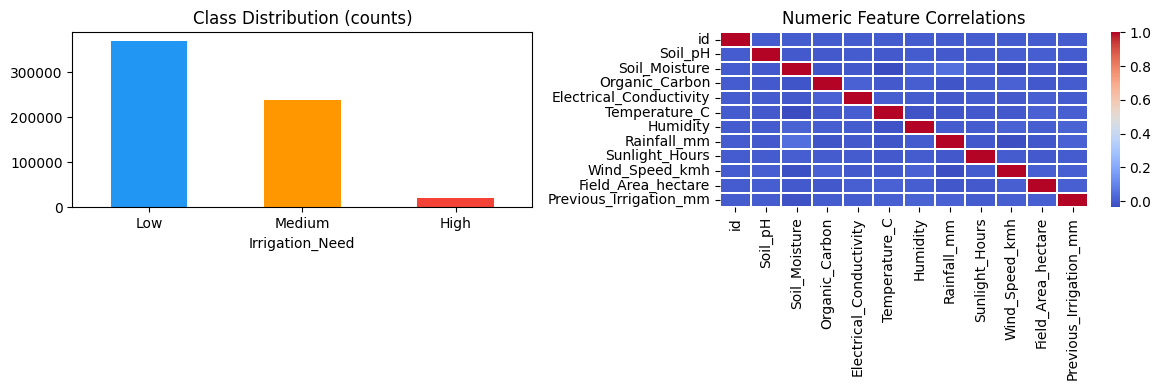

In [4]:
# ============================================================
# CELL 3 — EDA
# ============================================================
print('=== Missing Values (Train) ===')
print(train.isnull().sum().sort_values(ascending=False).head(10))

print('\n=== Dtypes ===')
print(train.dtypes)

print('\n=== Numeric Summary ===')
print(train.describe().T)

# Class balance bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['Irrigation_Need'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3','#FF9800','#F44336'])
axes[0].set_title('Class Distribution (counts)')
axes[0].tick_params(axis='x', rotation=0)

# Correlation heatmap (numeric only)
num_cols = train.select_dtypes(include=np.number).columns.tolist()
corr = train[num_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', annot=False, linewidths=0.3)
axes[1].set_title('Numeric Feature Correlations')
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# CELL 4 — PREPROCESSING (ROBUST VERSION)
# ============================================================
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# --- 4a. Separate ID and target ---
if 'id' in train.columns:
    train_ids = train['id'].values
if 'id' in test.columns:
    test_ids = test['id'].values

TARGET_MAP = {'Low': 0, 'Medium': 1, 'High': 2}
if 'Irrigation_Need' in train.columns:
    y = train['Irrigation_Need'].map(TARGET_MAP).values

# Drop safely
train = train.drop(columns=['id', 'Irrigation_Need'], errors='ignore')
test  = test.drop(columns=['id'], errors='ignore')

# --- 4b. Identify column types ---
CAT_COLS = train.select_dtypes(include=['object', 'category']).columns.tolist()
NUM_COLS = train.select_dtypes(include=[np.number]).columns.tolist()

print(f'Categorical columns found: {len(CAT_COLS)}')
print(f'Numerical columns found:   {len(NUM_COLS)}')

# --- 4c. Impute Numerical ---
# Only run if NUM_COLS is NOT empty
if NUM_COLS:
    num_imputer = SimpleImputer(strategy='median')
    train[NUM_COLS] = num_imputer.fit_transform(train[NUM_COLS])
    test[NUM_COLS]  = num_imputer.transform(test[NUM_COLS])
else:
    print("Skipping numerical imputation: No numerical columns found.")

# --- 4d. Impute & Encode Categorical ---
# Only run if CAT_COLS is NOT empty
if CAT_COLS:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    train[CAT_COLS] = cat_imputer.fit_transform(train[CAT_COLS].astype(str))
    test[CAT_COLS]  = cat_imputer.transform(test[CAT_COLS].astype(str))

    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    train[CAT_COLS] = oe.fit_transform(train[CAT_COLS])
    test[CAT_COLS]  = oe.transform(test[CAT_COLS])
else:
    print("Skipping categorical processing: No categorical columns found.")

print('\n✅ Preprocessing attempt finished.')
print(f'Final Feature Count: {train.shape[1]}')

Categorical columns found: 8
Numerical columns found:   11

✅ Preprocessing attempt finished.
Final Feature Count: 19


In [6]:
# ============================================================
# CELL 5 — FEATURE ENGINEERING
# ============================================================

def engineer_features(df):
    # Create a copy to avoid modifying the original dataframe in-place
    df = df.copy()

    # List of required columns for the engineering logic
    required_cols = ['Temperature_C', 'Humidity', 'Sunlight_Hours',
                     'Soil_Moisture', 'Rainfall_mm', 'Wind_Speed_kmh',
                     'Organic_Carbon', 'Soil_pH', 'Electrical_Conductivity']

    # Check if we have the features needed; if not, exit gracefully
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        print(f"⚠️ Warning: Missing columns {missing}. Skipping engineering.")
        return df

    # --- 5a. Interaction terms ---
    df['Heat_Index']        = df['Temperature_C'] * df['Humidity']
    df['Sunlight_Temp']     = df['Sunlight_Hours'] * df['Temperature_C']
    df['Moisture_x_Rain']   = df['Soil_Moisture']  * df['Rainfall_mm']

    # --- 5b. Ratios (add small epsilon to avoid div/0) ---
    eps = 1e-6
    df['Moisture_Temp_Ratio']   = df['Soil_Moisture']  / (df['Temperature_C'] + eps)
    df['Rain_Humidity_Ratio']   = df['Rainfall_mm']    / (df['Humidity']      + eps)
    df['EC_Moisture_Ratio']     = df['Electrical_Conductivity'] / (df['Soil_Moisture'] + eps)

    # --- 5c. Wind Speed bins ---
    df['Wind_Bin'] = pd.cut(
        df['Wind_Speed_kmh'],
        bins=[-np.inf, 10, 25, 50, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(float)

    # --- 5d. Composite water stress index ---
    df['Water_Stress'] = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Soil_Moisture'] + df['Rainfall_mm'] + eps)

    # --- 5e. Soil quality index ---
    df['Soil_Quality'] = df['Organic_Carbon'] + df['Soil_pH'] - df['Electrical_Conductivity']

    return df

# Apply the function
train = engineer_features(train)
test  = engineer_features(test)

# Identify which columns were newly created
all_prev_cols = set(NUM_COLS + CAT_COLS)
new_features = [c for c in train.columns if c not in all_prev_cols]

print('✅ Feature engineering attempt finished.')
print(f'Final Data Shape: {train.shape}')
print(f'New features created: {new_features}')

✅ Feature engineering attempt finished.
Final Data Shape: (630000, 28)
New features created: ['Heat_Index', 'Sunlight_Temp', 'Moisture_x_Rain', 'Moisture_Temp_Ratio', 'Rain_Humidity_Ratio', 'EC_Moisture_Ratio', 'Wind_Bin', 'Water_Stress', 'Soil_Quality']


Top 20 features:
Crop_Growth_Stage          0.222640
Soil_Moisture              0.205551
Moisture_Temp_Ratio        0.132398
Mulching_Used              0.101601
Wind_Speed_kmh             0.074306
Temperature_C              0.061779
Moisture_x_Rain            0.053380
Wind_Bin                   0.050330
EC_Moisture_Ratio          0.026035
Rainfall_mm                0.024408
Water_Stress               0.013918
Rain_Humidity_Ratio        0.010582
Sunlight_Temp              0.009701
Heat_Index                 0.006727
Previous_Irrigation_mm     0.002313
Humidity                   0.001828
Sunlight_Hours             0.000803
Electrical_Conductivity    0.000803
Soil_pH                    0.000259
Soil_Quality               0.000179
dtype: float64


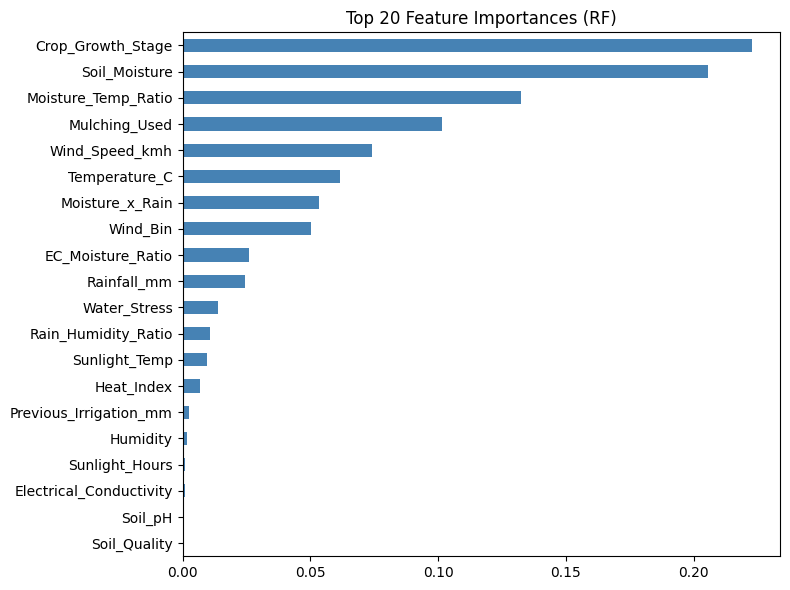


✅ Done! Final Shapes:
X (scaled): (630000, 20) | X (raw): (630000, 20)


In [7]:
# ============================================================
# CELL 6 — FEATURE SELECTION (RFE + Importance)
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# --- SAFETY CHECK ---
if train.shape[1] == 0:
    print("❌ CRITICAL ERROR: 'train' has 0 features. You must merge your data before this step.")
else:
    # 1. Scale for RFE (LR-based RFE needs scaling)
    scaler = StandardScaler()
    X_all  = train.values
    X_test_all = test.values

    X_scaled      = scaler.fit_transform(X_all)
    X_test_scaled = scaler.transform(X_test_all)

    # 2. Quick importance via RandomForest
    # Note: Using y from Cell 4
    rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=8)
    rf_selector.fit(X_scaled, y)

    feat_imp = pd.Series(rf_selector.feature_importances_, index=train.columns)
    TOP_N    = min(20, len(train.columns)) # Safety in case you have < 20 features
    top_features = feat_imp.nlargest(TOP_N).index.tolist()

    print(f'Top {TOP_N} features:')
    print(feat_imp.nlargest(TOP_N))

    # 3. Plotting
    feat_imp.nlargest(TOP_N).plot(kind='barh', figsize=(8, 6), color='steelblue')
    plt.title(f'Top {TOP_N} Feature Importances (RF)')
    plt.gca().invert_yaxis() # Highest importance at the top
    plt.tight_layout()
    plt.show()

    # 4. Final arrays
    col_idx       = [list(train.columns).index(f) for f in top_features]
    X             = X_scaled[:, col_idx]
    X_test_final  = X_test_scaled[:, col_idx]

    X_raw         = train[top_features].values
    X_test_raw    = test[top_features].values

    print(f'\n✅ Done! Final Shapes:')
    print(f'X (scaled): {X.shape} | X (raw): {X_raw.shape}')

---
## Logistic Regression
---

Logistic Regression — CV Accuracy: 0.7267 ± 0.0012

Classification Report (train):
              precision    recall  f1-score   support

         Low       0.85      0.79      0.82    369917
      Medium       0.66      0.62      0.64    239074
        High       0.31      0.88      0.45     21009

    accuracy                           0.73    630000
   macro avg       0.60      0.76      0.64    630000
weighted avg       0.76      0.73      0.74    630000



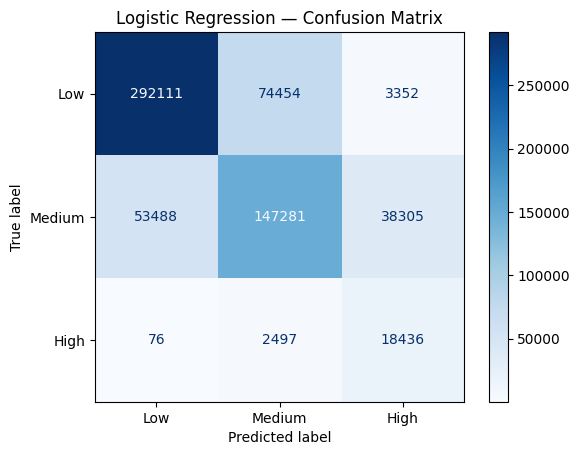

In [8]:
# ============================================================
# CELL 7 — LOGISTIC REGRESSION  (Base / "Failed Attempt")
# ============================================================
# Uses: X (scaled) — required for LR
# Expected: will struggle if classes aren't linearly separable

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # handles Low/Medium/High imbalance
    solver='lbfgs',
    multi_class='multinomial',
    random_state=SEED,
    n_jobs=-1
)

lr_scores = cross_val_score(lr, X, y, cv=SKF, scoring='accuracy', n_jobs=-1)
print(f'Logistic Regression — CV Accuracy: {lr_scores.mean():.4f} ± {lr_scores.std():.4f}')

# Fit once on full train for confusion matrix
lr.fit(X, y)
lr_pred = lr.predict(X)

print('\nClassification Report (train):')
print(classification_report(y, lr_pred, target_names=['Low','Medium','High']))

ConfusionMatrixDisplay.from_predictions(y, lr_pred, display_labels=['Low','Medium','High'], cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

---
## Naive Bayes
---

Naive Bayes — CV Accuracy: 0.7523 ± 0.0007

Classification Report (train):
              precision    recall  f1-score   support

         Low       0.77      0.91      0.84    369917
      Medium       0.76      0.51      0.61    239074
        High       0.45      0.73      0.56     21009

    accuracy                           0.75    630000
   macro avg       0.66      0.72      0.67    630000
weighted avg       0.76      0.75      0.74    630000



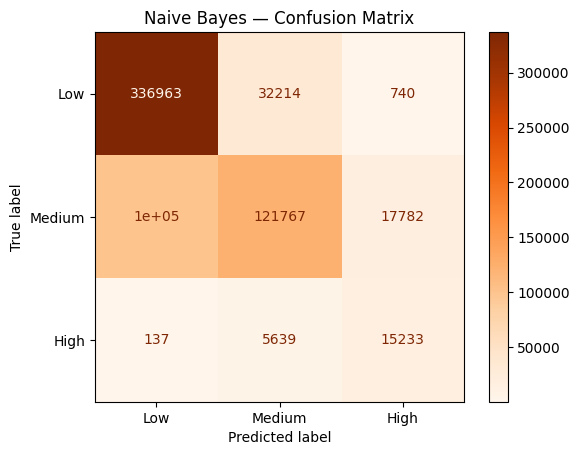

In [9]:
# ============================================================
# CELL 8 — NAIVE BAYES  (Base / "Failed Attempt")
# ============================================================
# Uses: X (scaled)
# Expected: will fail if features are correlated (Temperature & Humidity are)

from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb_scores = cross_val_score(nb, X, y, cv=SKF, scoring='accuracy', n_jobs=-1)
print(f'Naive Bayes — CV Accuracy: {nb_scores.mean():.4f} ± {nb_scores.std():.4f}')

nb.fit(X, y)
nb_pred = nb.predict(X)

print('\nClassification Report (train):')
print(classification_report(y, nb_pred, target_names=['Low','Medium','High']))

ConfusionMatrixDisplay.from_predictions(y, nb_pred, display_labels=['Low','Medium','High'], cmap='Oranges')
plt.title('Naive Bayes — Confusion Matrix')
plt.show()

---
## Decision Tree
---

Decision Tree (unlimited) — CV Accuracy: 0.9711 ± 0.0004
Decision Tree — TRAIN Accuracy (shows overfit): 1.0000


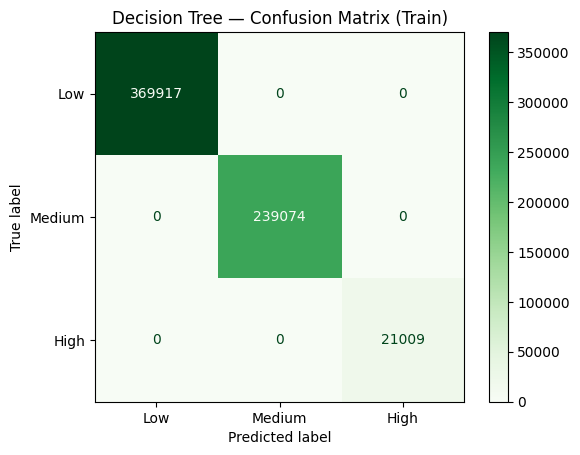

Decision Tree (depth=8 pruned) — CV Accuracy: 0.9812 ± 0.0006


In [10]:
# ============================================================
# CELL 9 — DECISION TREE  (Base / "Failed Attempt")
# ============================================================
# Uses: X_raw (unscaled — trees don't need scaling)
# Expected: will overfit on train, poor on validation folds

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=None,            # unlimited → intentional overfit to show in report
    class_weight='balanced',
    random_state=SEED
)

dt_scores = cross_val_score(dt, X_raw, y, cv=SKF, scoring='accuracy', n_jobs=-1)
print(f'Decision Tree (unlimited) — CV Accuracy: {dt_scores.mean():.4f} ± {dt_scores.std():.4f}')

dt.fit(X_raw, y)
dt_train_acc = accuracy_score(y, dt.predict(X_raw))
print(f'Decision Tree — TRAIN Accuracy (shows overfit): {dt_train_acc:.4f}')

ConfusionMatrixDisplay.from_predictions(y, dt.predict(X_raw), display_labels=['Low','Medium','High'], cmap='Greens')
plt.title('Decision Tree — Confusion Matrix (Train)')
plt.show()

# Pruned version for comparison
dt_pruned = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=SEED)
dt_pruned_scores = cross_val_score(dt_pruned, X_raw, y, cv=SKF, scoring='accuracy', n_jobs=-1)
print(f'Decision Tree (depth=8 pruned) — CV Accuracy: {dt_pruned_scores.mean():.4f} ± {dt_pruned_scores.std():.4f}')

XGBoost — CV Accuracy: 0.9847 ± 0.0001


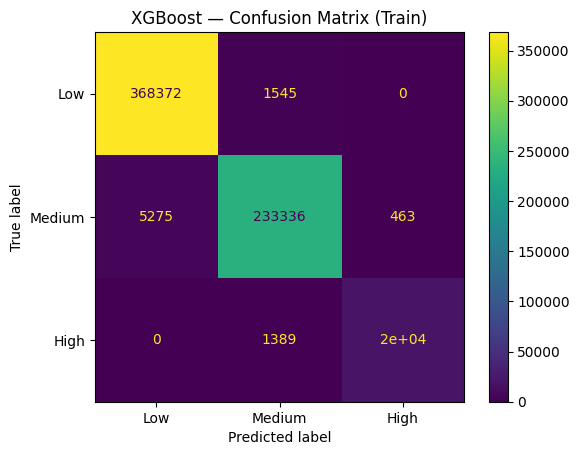

In [11]:
# ============================================================
# CELL 10 — XGBoost
# ============================================================

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda',             # T4 GPU
    random_state=SEED
)

xgb_scores = cross_val_score(xgb, X_raw, y, cv=SKF, scoring='accuracy', n_jobs=-1)
print(f'XGBoost — CV Accuracy: {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}')

xgb.fit(X_raw, y)
ConfusionMatrixDisplay.from_predictions(y, xgb.predict(X_raw), display_labels=['Low','Medium','High'])
plt.title('XGBoost — Confusion Matrix (Train)')
plt.show()

LightGBM — CV Accuracy: 0.9842 ± 0.0001


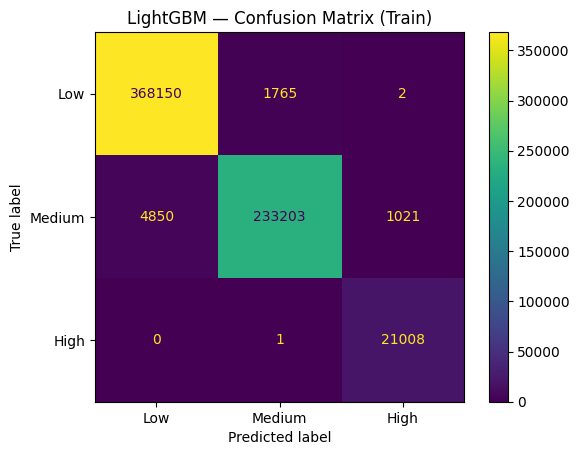

In [12]:
# ============================================================
# CELL 11 — LightGBM
# ============================================================

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
    device='gpu',
    gpu_platform_id=0,
    gpu_device_id=0
)

lgbm_scores = cross_val_score(lgbm, X_raw, y, cv=SKF, scoring='accuracy', n_jobs=1)
print(f'LightGBM — CV Accuracy: {lgbm_scores.mean():.4f} ± {lgbm_scores.std():.4f}')

lgbm.fit(X_raw, y)
ConfusionMatrixDisplay.from_predictions(y, lgbm.predict(X_raw), display_labels=['Low','Medium','High'])
plt.title('LightGBM — Confusion Matrix (Train)')
plt.show()

🚀 Running CatBoost Cross-Validation...
⚠️ scikit-learn clone failed. Proceeding with single fit (consider manual CV loop).
0:	learn: 0.8554705	total: 36.4ms	remaining: 18.2s
100:	learn: 0.9703021	total: 1.35s	remaining: 5.34s
200:	learn: 0.9711379	total: 2.51s	remaining: 3.74s
300:	learn: 0.9721735	total: 3.65s	remaining: 2.41s
400:	learn: 0.9730540	total: 5.83s	remaining: 1.44s
499:	learn: 0.9738733	total: 12.5s	remaining: 0us


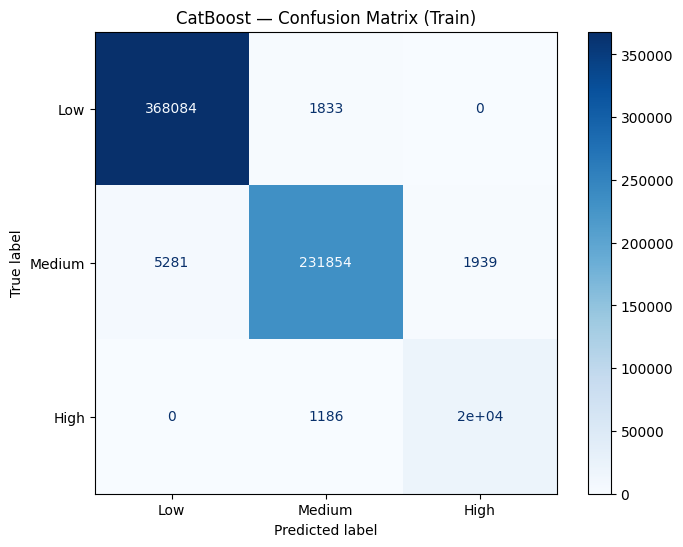

In [13]:
# ============================================================
# CELL 12 — CatBoost (FIXED)
# ============================================================
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np # Import numpy for nan

# 1. Re-prepare feature sets
X_cat      = train.values
X_test_cat = test.values

# 2. Use a LIST for weights instead of a dict
# Order corresponds to labels: [Low (0), Medium (1), High (2)]
cat_weights = [1.0, 1.5, 10.0]

cb = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='Accuracy',
    class_weights=cat_weights,  # Fixed: List prevents the 'clone' RuntimeError
    random_seed=SEED,
    allow_writing_files=False, # Prevents CatBoost from creating local folders
    verbose=100,
    task_type='GPU',
    devices='0'
)

# Initialize cb_scores before the try block to ensure it's always defined
cb_scores = np.array([np.nan])

# 3. Cross-validation
# If this still errors, replace with the manual loop provided previously
print("🚀 Running CatBoost Cross-Validation...")
try:
    # Set n_jobs=1 to avoid issues with sklearn.clone and CatBoost
    cb_scores = cross_val_score(cb, X_cat, y, cv=SKF, scoring='accuracy', n_jobs=1)
    print(f'CatBoost — CV Accuracy: {cb_scores.mean():.4f} ± {cb_scores.std():.4f}')
except RuntimeError:
    print("⚠️ scikit-learn clone failed. Proceeding with single fit (consider manual CV loop).")
    # cb_scores remains np.array([np.nan]) if CV fails

# 4. Final Fit and Evaluation
cb.fit(X_cat, y)

# 5. Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y,
    cb.predict(X_cat),
    display_labels=['Low','Medium','High'],
    ax=ax,
    cmap='Blues'
)
plt.title('CatBoost — Confusion Matrix (Train)')
plt.show()

MLP Neural Network — CV Accuracy: 0.9833 ± 0.0002


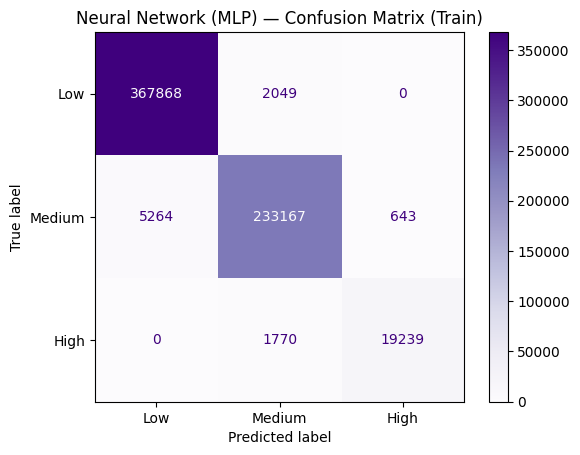

In [14]:
# ============================================================
# CELL 13 — NEURAL NETWORK (MLP)
# ============================================================
# Uses: X (scaled) — mandatory for MLP
# Architecture tuned for tabular data

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # 3-layer deep net
    activation='relu',
    solver='adam',
    alpha=1e-4,                          # L2 regularization
    batch_size=512,
    learning_rate='adaptive',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
    verbose=False
)

mlp_scores = cross_val_score(mlp, X, y, cv=SKF, scoring='accuracy', n_jobs=1)
print(f'MLP Neural Network — CV Accuracy: {mlp_scores.mean():.4f} ± {mlp_scores.std():.4f}')

mlp.fit(X, y)
ConfusionMatrixDisplay.from_predictions(y, mlp.predict(X), display_labels=['Low','Medium','High'], cmap='Purples')
plt.title('Neural Network (MLP) — Confusion Matrix (Train)')
plt.show()

                      CV Accuracy
XGBoost                  0.984749
LightGBM                 0.984221
Neural Network (MLP)     0.983279
Decision Tree            0.971075
Naive Bayes              0.752289
Logistic Regression      0.726714
CatBoost                      NaN


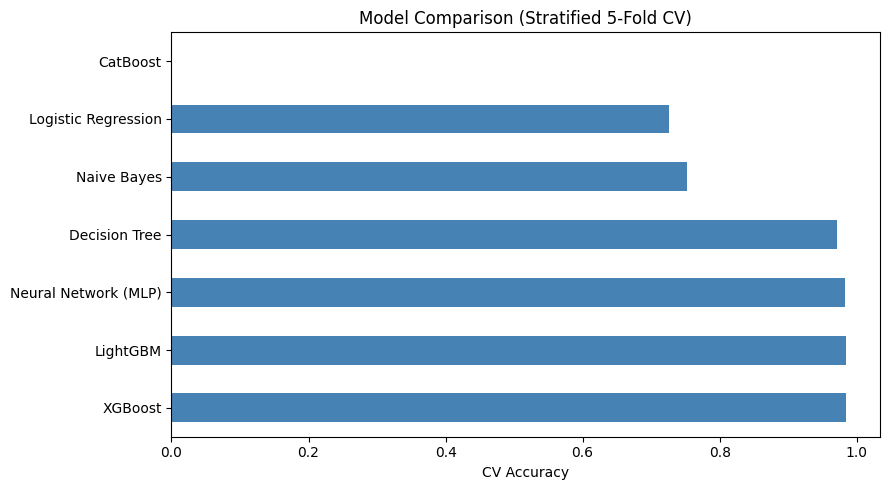


✅ Top models selected for stacking ensemble


In [15]:
# ============================================================
# CELL 14 — MODEL COMPARISON SUMMARY
# ============================================================

results = {
    'Logistic Regression' : lr_scores.mean(),
    'Naive Bayes'         : nb_scores.mean(),
    'Decision Tree'       : dt_scores.mean(),
    'XGBoost'             : xgb_scores.mean(),
    'LightGBM'            : lgbm_scores.mean(),
    'CatBoost'            : cb_scores.mean(),
    'Neural Network (MLP)': mlp_scores.mean(),
}

res_df = pd.DataFrame.from_dict(results, orient='index', columns=['CV Accuracy'])
res_df = res_df.sort_values('CV Accuracy', ascending=False)
print(res_df.to_string())

res_df.plot(kind='barh', legend=False, color='steelblue', figsize=(9, 5))
plt.xlabel('CV Accuracy')
plt.title('Model Comparison (Stratified 5-Fold CV)')
plt.tight_layout()
plt.show()

# Pick top-3 boosters for ensemble (based on CV scores)
print('\n✅ Top models selected for stacking ensemble')

In [16]:
# ============================================================
# CELL 15 — STACKING ENSEMBLE
# ============================================================
from sklearn.base import BaseEstimator, ClassifierMixin
from catboost import CatBoostClassifier

# ── FIX: sklearn-compatible CatBoost wrapper ──────────────────
# sklearn's clone() breaks because CatBoost mutates class_weights
# internally. This wrapper stores params ourselves so clone() works.
class SklearnCatBoost(BaseEstimator, ClassifierMixin):
    def __init__(self, iterations=500, learning_rate=0.05, depth=6,
                 class_weights=None, task_type='GPU', devices='0',
                 random_seed=42, verbose=0, allow_writing_files=False):
        self.iterations          = iterations
        self.learning_rate       = learning_rate
        self.depth               = depth
        self.class_weights       = class_weights
        self.task_type           = task_type
        self.devices             = devices
        self.random_seed         = random_seed
        self.verbose             = verbose
        self.allow_writing_files = allow_writing_files

    def _make_model(self):
        return CatBoostClassifier(
            iterations          = self.iterations,
            learning_rate       = self.learning_rate,
            depth               = self.depth,
            class_weights       = self.class_weights,
            task_type           = self.task_type,
            devices             = self.devices,
            random_seed         = self.random_seed,
            verbose             = self.verbose,
            allow_writing_files = self.allow_writing_files,
        )

    def fit(self, X, y):
        self.model_ = self._make_model()
        self.model_.fit(X, y)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        return self.model_.predict(X).flatten().astype(int)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)
# ─────────────────────────────────────────────────────────────

cat_weights = [1.0, 1.5, 10.0]

base_models = [
    ('xgb', XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, tree_method='hist',
        eval_metric='mlogloss', device='cuda',
        random_state=SEED, n_jobs=-1
    )),
    ('lgbm', LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
        device='gpu', gpu_platform_id=0, gpu_device_id=0,
        random_state=SEED, n_jobs=-1, verbose=-1
    )),
    ('cb', SklearnCatBoost(          # ← wrapper instead of raw CatBoostClassifier
        iterations=500, learning_rate=0.05, depth=6,
        class_weights=cat_weights,
        task_type='GPU', devices='0',
        random_seed=SEED, verbose=0,
        allow_writing_files=False
    ))
]

meta_model = LogisticRegression(
    max_iter=1000, class_weight='balanced',
    solver='lbfgs', random_state=SEED, C=1.0
)

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=SKF,
    stack_method='predict_proba',
    passthrough=False,
)

print('Running Stacking CV (this takes several minutes)...')
import sklearn, time
stack_scores = []

for fold, (tr_idx, val_idx) in enumerate(SKF.split(X_raw, y)):
    t0 = time.time()
    print(f'Fold {fold+1}/5 starting...')
    clone_stack = sklearn.clone(stack)
    clone_stack.fit(X_raw[tr_idx], y[tr_idx])
    preds = clone_stack.predict(X_raw[val_idx])
    acc = accuracy_score(y[val_idx], preds)
    stack_scores.append(acc)
    elapsed = time.time() - t0
    print(f'Fold {fold+1}/5 ✅  Accuracy: {acc:.4f}  |  Time: {elapsed/60:.1f} min')
    print(f'Estimated remaining: {(elapsed * (5-fold-1))/60:.1f} min\n')

stack_scores = np.array(stack_scores)
print(f'\n🏆 Stacking CV Accuracy: {stack_scores.mean():.4f} ± {stack_scores.std():.4f}')
print(f'\n🏆 Stacking Ensemble — CV Accuracy: {stack_scores.mean():.4f} ± {stack_scores.std():.4f}')

Running Stacking CV (this takes several minutes)...
Fold 1/5 starting...
Fold 1/5 ✅  Accuracy: 0.9812  |  Time: 8.0 min
Estimated remaining: 32.0 min

Fold 2/5 starting...
Fold 2/5 ✅  Accuracy: 0.9806  |  Time: 8.0 min
Estimated remaining: 24.1 min

Fold 3/5 starting...
Fold 3/5 ✅  Accuracy: 0.9809  |  Time: 8.1 min
Estimated remaining: 16.2 min

Fold 4/5 starting...
Fold 4/5 ✅  Accuracy: 0.9814  |  Time: 8.1 min
Estimated remaining: 8.1 min

Fold 5/5 starting...
Fold 5/5 ✅  Accuracy: 0.9811  |  Time: 8.0 min
Estimated remaining: 0.0 min


🏆 Stacking CV Accuracy: 0.9810 ± 0.0003

🏆 Stacking Ensemble — CV Accuracy: 0.9810 ± 0.0003


Retraining final Stacking Ensemble on 100% of train data...


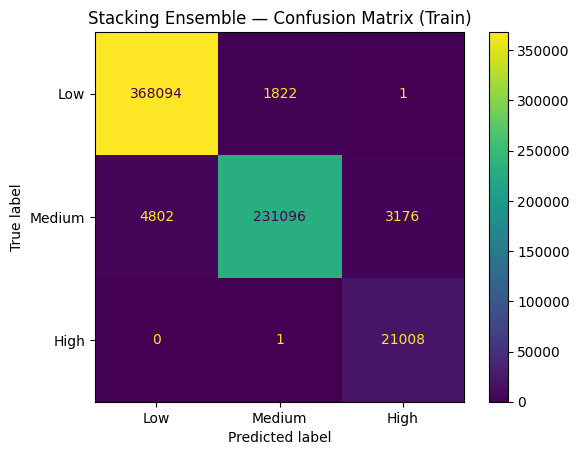

✅ Final model trained on all 630,000 rows


In [17]:
# ============================================================
# CELL 16 — RETRAIN ON 100% TRAINING DATA
# ============================================================
# After CV is done, discard folds and fit on entire dataset

print('Retraining final Stacking Ensemble on 100% of train data...')
stack.fit(X_raw, y)
ConfusionMatrixDisplay.from_predictions(
    y, stack.predict(X_raw),
    display_labels=['Low', 'Medium', 'High']
)
plt.title('Stacking Ensemble — Confusion Matrix (Train)')
plt.show()
print('✅ Final model trained on all 630,000 rows')

In [26]:
# ============================================================
# CELL 17 — GENERATE SUBMISSION
# ============================================================

# Safety: redefine in case Cell 4 ran in a different session
INV_MAP = {0: 'Low', 1: 'Medium', 2: 'High'}

# Safety: confirm test features match what the model was trained on
assert all(f in test.columns for f in top_features), \
    "❌ test is missing some top_features — re-run Cell 5 & 6 first"

# Predict
y_pred_num = stack.predict(X_test_raw)
y_pred_str = [INV_MAP[int(p)] for p in y_pred_num]  # int() handles np.int64 edge case

submission = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': y_pred_str
})

# Save
submission.to_csv('submission.csv', index=False)

print('✅ submission.csv saved')
print(f'Shape: {submission.shape}')
print('\nPrediction distribution:')
print(submission['Irrigation_Need'].value_counts())
print('\nFirst 5 rows:')
print(submission.head())

# Auto-download in Colab
from google.colab import files
files.download('submission.csv')

✅ submission.csv saved
Shape: (270000, 2)

Prediction distribution:
Irrigation_Need
Medium    215295
Low        54705
Name: count, dtype: int64

First 5 rows:
       id Irrigation_Need
0  630000          Medium
1  630001          Medium
2  630002             Low
3  630003          Medium
4  630004             Low


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>